# H_SFTY_2_RF_hyp_tune_F1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/PYTHON_OUTPUTS/df_new.xlsx')
#df_new = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/HomeSafety_2/RawData/Household_data/RESIDENTIAL_OXON_anon.xlsx')

In [3]:
df_new.columns

Index(['Unnamed: 0', 'Addressbase UPRN', 'ABP_Classification_Desc',
       'ABP_Classification_Code', 'Tenure_Desc', 'AgeBracket_EldParent',
       '(H) Age - Fine', '(H) Presence of Elderly Parent',
       '(H) Number of Adults in Household', '(H) Family Lifestage v3',
       '(H) Length of Residency', '(H) Affluence v2', '(H) Water Poverty Flag',
       '(H) Fuel Poverty v2 Flag', '(H) Number of Children v3',
       '(H) Household Income v3 - Bands', 'Household Acorn Category',
       'Household Acorn Category Description', 'Household Acorn Type_x',
       'Household Acorn Type Description_x', 'Dependent Locality', 'Town',
       'Station_Ground_Code', 'LSOA11CD', 'Local Custodian Name',
       'Household Acorn Group', 'Household Acorn Group Description',
       'Household Acorn Type_y', 'Household Acorn Type Description_y',
       'Output Area', 'Easting', 'Northing', 'CREATION_DATE',
       'FRSIncidentIdentifier', 'Year', 'Fiscal_Year', 'TimeOfCall',
       'ResponsiblePartyStatio

In [6]:
df = df_new.copy()   #
df = df.drop(columns=['Addressbase UPRN','Unnamed: 0','Easting', 'Northing', 'CREATION_DATE',
       'FRSIncidentIdentifier', 'Year', 'Fiscal_Year', 'TimeOfCall',
       'ResponsiblePartyStationId', 'IncidentCategory', 'Property_Type',
       'Property_Description', 'Description', 'Property_Code',
       'VictimsInvolved', 'VictimType', 'WasRescued', 'Victim_Category',
       'EvacuationAssistanceInvolved', 'EquipmentUsed','ABP_Classification_Desc',
        'Household Acorn Category Description','Household Acorn Type Description_x',
        'Household Acorn Group Description', 'Household Acorn Type Description_y',
        '(H) Water Poverty Flag', '(H) Fuel Poverty v2 Flag','Dependent Locality',
                      'Town','Station_Ground_Code',
                      '(H) Presence of Elderly Parent','AgeBracket_EldParent',
                      'Output Area', 'LSOA11CD'
                      ])

In [7]:
df.head(2)

,ABP_Classification_Code,Tenure_Desc,(H) Age - Fine,(H) Number of Adults in Household,(H) Family Lifestage v3,(H) Length of Residency,(H) Affluence v2,(H) Number of Children v3,(H) Household Income v3 - Bands,Household Acorn Category,Household Acorn Type_x,Local Custodian Name,Household Acorn Group,Household Acorn Type_y,Incident?
0,RD02,Owner,11,4,12,11,19,0,8,1,5,West Oxfordshire,1,2,N
1,RD03,Owner,8,2,9,11,16,0,3,1,9,West Oxfordshire,2,3,N


In [8]:
df['ABP_Classification_Code'].value_counts()

ABP_Classification_Code
RD06    24290
RD02    23700
RD03    17557
RD04    16767
Name: count, dtype: int64

In [9]:
df.rename(columns = {'Incident?':'INCIDENT'}, inplace = True)
df['INCIDENT'].value_counts(normalize = True)

INCIDENT
N    0.969203
Y    0.030797
Name: proportion, dtype: float64

In [10]:
df.INCIDENT.value_counts()

INCIDENT
N    79779
Y     2535
Name: count, dtype: int64

In [11]:
df['INCIDENT'] = df['INCIDENT'].replace({'Y': '1', 'N': '0', '': pd.NA}).astype(pd.Int8Dtype())

### SPLIT THE DATA: Next, you define the target and features. This means separating the dataset into the input variables (X) and the target variable (y), which in your case is the Incident column.

In [12]:
cols = []
for c in df.columns:
    cols.append(c)
cols

['ABP_Classification_Code',
 'Tenure_Desc',
 '(H) Age - Fine',
 '(H) Number of Adults in Household',
 '(H) Family Lifestage v3',
 '(H) Length of Residency',
 '(H) Affluence v2',
 '(H) Number of Children v3',
 '(H) Household Income v3 - Bands',
 'Household Acorn Category',
 'Household Acorn Type_x',
 'Local Custodian Name',
 'Household Acorn Group',
 'Household Acorn Type_y',
 'INCIDENT']

In [13]:
# target data
y = df[cols[-1]]
y.value_counts()

INCIDENT
0    79779
1     2535
Name: count, dtype: Int64

In [14]:
X_cols = cols[0:len(cols)-1]
X = df[df.columns.intersection(X_cols)]
X.shape

(82314, 14)

#### After defining the X, y features: ...perform a train/test split. The reason we do this relatively early is so that part of the data remains completely unseen during training. This allows us to properly evaluate whether the model generalises well.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state = 42)

## Training set datatype == Int

In [16]:
X_train_int = X_train.dtypes[X_train.dtypes == 'int64']
X_train_int = X_train.select_dtypes('int64')
print(f'The are {X_train_int.shape[1]} float64 formats present >>>') 

X_train_int_features = X_train_int.columns
#X_train_int_features

The are 11 float64 formats present >>>


### Training set. datatype == Object/str

In [17]:
X_train_obj = X_train.select_dtypes('str')
X_train_obj_features = X_train_obj.columns
#X_train_obj_features

# Pipeline: Random_Forest

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# 1. Define which columns get which treatment

num_cols = X_train_int_features
#num_cols = ['(H) Age - Fine', '(H) Number of Adults in Household', '(H) Length of Residency', '(H) Affluence v2']
cat_cols = X_train_obj_features
#cat_cols = ['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name', 'LSOA11CD']
cat_cols

Index(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'], dtype='str')

In [19]:
# 2. Create the transformers
from sklearn.impute import SimpleImputer

preprocessor = ColumnTransformer(
    transformers=[
        ## additional impute in case of missing values in future datasets
        #('impute', SimpleImputer(strategy = "median"), num_cols),
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='drop') # This automatically drops LSOA11CD and anything not listed above
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [20]:
# 3. Bundle it all with your model
from sklearn.ensemble import RandomForestClassifier

pipeline_Random_Forest = Pipeline(
    steps=
                                  [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced')) 
                                  ]
)

# Note: class_weight='balanced' forces the model to pay attention to the 3% of fires.
pipeline_Random_Forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [21]:
# 4. Fit the pipeline on training data
import time
start_time = time.time()

pipeline_Random_Forest.fit(X_train, y_train)

print("--- %s seconds ---" % (time.time() - start_time))

--- 9.540987968444824 seconds ---


In [22]:
from sklearn.metrics import precision_score, roc_auc_score, mean_squared_error, accuracy_score, recall_score, classification_report, roc_curve, confusion_matrix

# TRAINING SET metrics

In [23]:
# 4. Fit the pipeline on training data
# we can get performance of the model on the TRAIN data set from 
y_train_pred_RF =  pipeline_Random_Forest.predict(X_train)
y_train_pred_RF

array([0., 0., 0., ..., 0., 0., 0.])

In [24]:
# import the metrics class for TRAINING SET
from sklearn import metrics
# Run confusion matrix on TRAINING SET for LOGREG
cnf_matrix_TRAIN = metrics.confusion_matrix(y_train, y_train_pred_RF, labels=[0,  1] )
print("RandomForest(X_train) \n\nconfusion matrix:")
cnf_matrix_TRAIN


RandomForest(X_train) 

confusion matrix:


array([[63201,   622],
       [   14,  2014]])

In [23]:
#sns.heatmap(cnf_matrix_TRAIN, annot =True, fmt = ".1f")
#plt.show()

In [25]:
y_train_pred_RF_ACCURACY = metrics.accuracy_score(y_train, y_train_pred_RF)
y_train_pred_RF_PRECISION = metrics.precision_score(y_train, y_train_pred_RF)
y_train_pred_RF_RECALL = metrics.recall_score(y_train, y_train_pred_RF)
y_train_pred_RF_PF1 = metrics.f1_score(y_train, y_train_pred_RF)
y_train_pred_RF_ACCURACY, y_train_pred_RF_PRECISION, y_train_pred_RF_RECALL,  y_train_pred_RF_PF1

(0.9903418323184158,
 0.7640364188163885,
 0.9930966469428008,
 0.8636363636363636)

In [25]:
report_dict_TRAIN = classification_report(y_train, y_train_pred_RF, output_dict=True)

# Convert to a DataFrame and transpose to get classes as rows
metrics_table_TRAIN = pd.DataFrame(report_dict_TRAIN).transpose().drop(columns = ['support'])
metrics_table_TRAIN.columns = [str(col) + '_TRAIN' for col in metrics_table_TRAIN.columns]

#metrics_table_TRAIN.columns = ['TRAIN_'+ str(col)  for col in metrics_table_TRAIN.columns]
metrics_table_TRAIN = pd.DataFrame(metrics_table_TRAIN.loc[ '1.0' , : ].T)
metrics_table_TRAIN

,1.0
precision_TRAIN,0.765175
recall_TRAIN,0.994576
f1-score_TRAIN,0.864923


In [26]:
## TRAINING SET: 

from sklearn.metrics import classification_report
target_names = ['0', '1']
print("RandomForest(X_train)\n\nClassification Report:")
print(classification_report(y_train, y_train_pred_RF, target_names=target_names))

RandomForest(X_train)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     63823
           1       0.77      0.99      0.86      2028

    accuracy                           0.99     65851
   macro avg       0.88      0.99      0.93     65851
weighted avg       0.99      0.99      0.99     65851



## TEST SET metrics

In [75]:
# 5. Evaluate on TEST data (which you haven't done yet!)

y_test_pred_RF = pipeline_Random_Forest.predict(X_test)
y_test_pred_RF

array([0., 0., 0., ..., 0., 0., 0.])

In [76]:
# Run confusion matrix on TEST SET for RANDOM FOREST
cnf_matrix_TEST = metrics.confusion_matrix(y_test, y_test_pred_RF)
print("RANDOM_FOREST(TEST):\nConfusion Matrix")
cnf_matrix_TEST

RANDOM_FOREST(TEST):
Confusion Matrix


array([[15760,   196],
       [  303,   204]])

In [77]:
## TEST SET: 

from sklearn.metrics import classification_report
target_names = ['0', '1']
print("RANDOM_FOREST(TEST SET)")
print(classification_report(y_test, y_test_pred_RF, target_names=target_names))

RANDOM_FOREST(TEST SET)
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     15956
           1       0.51      0.40      0.45       507

    accuracy                           0.97     16463
   macro avg       0.75      0.70      0.72     16463
weighted avg       0.97      0.97      0.97     16463



In [30]:
report_dict_TEST = classification_report(y_test, y_test_pred_RF, output_dict=True)

# Convert to a DataFrame and transpose to get classes as rows
metrics_table_TEST = pd.DataFrame(report_dict_TEST).transpose().drop(columns = ['support'])
metrics_table_TEST.columns = [str(col) + '_TEST' for col in metrics_table_TEST.columns]
metrics_table_TEST = pd.DataFrame(metrics_table_TEST.loc[ '1.0' , : ].T)
metrics_table_TEST

,1.0
precision_TEST,0.547945
recall_TEST,0.394477
f1-score_TEST,0.458716


In [31]:
result = pd.concat([metrics_table_TRAIN, metrics_table_TEST], axis=1)
result

,1.0,1.0
precision_TRAIN,0.765175,NaN
recall_TRAIN,0.994576,NaN
f1-score_TRAIN,0.864923,NaN
precision_TEST,NaN,0.547945
recall_TEST,NaN,0.394477
f1-score_TEST,NaN,0.458716


<Axes: >

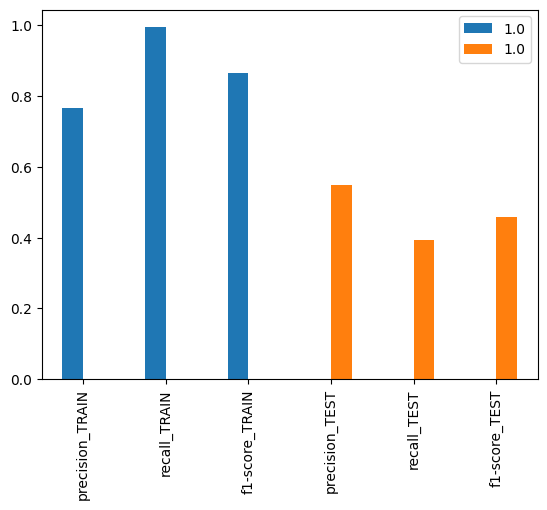

In [32]:
result.plot(kind = 'bar', legend = True)

In [33]:
#logit_roc_auc = roc_auc_score(y_train, y_train_pred_RF)
#fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_RF)

y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
#model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    y_test_pred_proba_RF_baseline)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba_RF_baseline)
y_test_pred_proba_RF_baseline

array([0.08, 0.  , 0.  , ..., 0.07, 0.  , 0.  ])

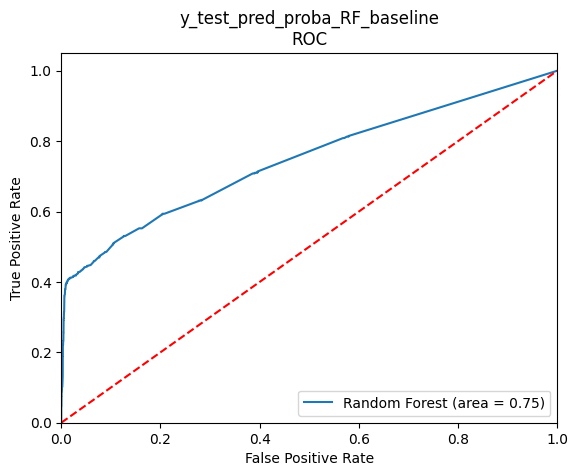

In [34]:
# ROC curve for the RandomForest baseline

#logit_roc_auc = roc_auc_score(y_train, y_train_pred_RF)
#fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_RF)

y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
#model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    y_test_pred_proba_RF_baseline)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba_RF_baseline)
y_test_pred_proba_RF_baseline
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('y_test_pred_proba_RF_baseline\nROC')
plt.legend(loc="lower right")
plt.show()

# test set metrics is dropping 
# There is some Overfitting occuring
# -->> which means we need to optimise the model.

# HyperParameter tuning : GRIDSEARCH_CV

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score 
from sklearn.metrics._scorer import _SCORERS
#sorted(_SCORERS.keys())

In [27]:
# Take a look at which hyperparameters are on offer

rf = RandomForestClassifier(random_state = 42)
print('Random Forest Parameters currently in use:\n')
print(rf.get_params())

Random Forest Parameters currently in use:

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### model = pipeline_Random_Forest

In [28]:
### max depth rule of thumb to use the logbase(2)(number features)

In [29]:
'''
import math as math
max_max_depth = int(math.log(df.shape[1],2))

max_depth_list = []  #np.linspace(1,max_max_depth)
for i in range(1,max_max_depth+1):
    max_depth_list.append(i)
max_depth_list
'''

'\nimport math as math\nmax_max_depth = int(math.log(df.shape[1],2))\n\nmax_depth_list = []  #np.linspace(1,max_max_depth)\nfor i in range(1,max_max_depth+1):\n    max_depth_list.append(i)\nmax_depth_list\n'

In [30]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint


In [31]:
RandomizedSearchCV

sklearn.model_selection._search.RandomizedSearchCV

In [32]:
model = pipeline_Random_Forest

#hyperparams = {'max_depth': [10, 15,20]}
'''
param_grid = {'classifier__max_depth'         : [6,7,8],
              'classifier__min_samples_split' : [2,3,4],
              'classifier__min_samples_leaf'  : [2,3,4],
              #'classifer__class_weight'       : [{'0':1, '1':2},
               #                                   {'0':2 , '1':1}],
              'classifier__max_leaf_nodes'    : [15,17,18,19,20] ,  
              'classifier__n_estimators'      : [200,225, 250]
             }
'''


param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [None, 8, 12, 16, 20, 30],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__max_leaf_nodes': [None, 50, 100, 200, 500],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}
param_distributions_2 = {
    'classifier__n_estimators': [ 500, 550, 600],
    'classifier__max_depth': [35, 40, 45],
    'classifier__min_samples_split': [8,9,10],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_leaf_nodes': [None,1, 10],
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}
#my_metrics = [{'classifier__C': ['accuracy', 'precision', 'recall_macro', 'f1_macro']}]

#RF_gridsearch = GridSearchCV(estimator = model, param_grid = param_grid, cv = 4, scoring = 'precision', n_jobs=-1, verbose=2)#, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs',  return_train_score=False)  # use different metrics

# 3. Set up the RandomizedSearchCV
RF_random_search = RandomizedSearchCV(
    estimator= model,
    scoring = 'f1_macro',
    param_distributions=param_distributions_2,
    n_iter=20,       # Number of random combinations to try
    cv=5,            # 5-fold cross-validation
    random_state=42, # Ensures reproducibility
    n_jobs=-1        # Uses all available CPU cores
)


#pipeline_Random_Forest.get_params()
#RF_gridsearch.fit(X_train, y_train)

#RF_random_search.fit(X_train,y_train)

# ##### Next part will take a while

In [33]:
import time
start_time = time.time()

In [34]:
RF_random_search.fit(X_train,y_train)

print("--- %s seconds ---" % (time.time() - start_time))

C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\pw347789\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\pw

--- 2327.373889684677 seconds ---


In [35]:
#print(RF_gridsearch.best_score_)
print(RF_random_search.best_score_)

0.6883897141732568


In [36]:
#print(RF_gridsearch.best_params_)
print(RF_random_search.best_params_)

{'classifier__n_estimators': 600, 'classifier__min_samples_split': 8, 'classifier__min_samples_leaf': 2, 'classifier__max_leaf_nodes': None, 'classifier__max_features': None, 'classifier__max_depth': 40, 'classifier__class_weight': 'balanced_subsample'}


In [37]:
#print(RF_gridsearch.best_estimator_)
print(RF_random_search.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['(H) Age - Fine', '(H) Number of Adults in Household',
       '(H) Family Lifestage v3', '(H) Length of Residency',
       '(H) Affluence v2', '(H) Number of Children v3',
       '(H) Household Income v3 - Bands', 'Household Acorn Category',
       'Household Acorn Type_x', 'Household Acorn Group',
       'Household Acorn Type_y'],
      dtype='str')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['ABP_Classification_Code', 'Tenure_Desc', 'Local Custodian Name'], dtype='str'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        max_depth=40, max_features=None,
            

In [ ]:
#print(gridsearch.cv_results_.keys(), '\n')

#print('mean_test_score', RF_gridsearch.cv_results_['mean_test_score'])

#print('rank_test_score', RF_gridsearch.cv_results_['rank_test_score'])

#print(gridsearch.best_estimator_)
## is there a consistency here? in terms of the range of the mean_test_score

#dfs = pd.DataFrame([RF_gridsearch.cv_results_['mean_test_score'],RF_gridsearch.cv_results_['rank_test_score']], index = ['mean_test_score','rank_test_score'])
#dfs

# .....

### To grab best model:

##### Grab the best model best_logreg_model = logreg_gridsearch.best_estimator_

In [38]:
#best_RF_model = RF_gridsearch.best_estimator_
best_RF_model = RF_random_search.best_estimator_

In [39]:
y_pred_best_RF_model = best_RF_model.predict(X_test)
y_pred_best_RF_model

array([0., 0., 0., ..., 0., 0., 0.])

In [40]:
print(classification_report(y_test, y_pred_best_RF_model))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98     15956
         1.0       0.51      0.40      0.45       507

    accuracy                           0.97     16463
   macro avg       0.75      0.69      0.72     16463
weighted avg       0.97      0.97      0.97     16463



### View the best combination of hyperparameters print("Best Parameters:", logreg_gridsearch.best_params_)

In [ ]:
#print("Best Parameters:", RF_gridsearch.best_params_)
print("Best Parameters: ", RF_random_search.best_params_)

# PRECISION score

In [ ]:
#print("Best CV Precision Score:", RF_gridsearch.best_score_)
#print("Best CV Precision Score:", RF_random_search.best_score_)

#  F1 score

In [41]:
#print("Best CV Recall Score:", RF_gridsearch.best_score_)
print("Best CV F1 Score:", RF_random_search.best_score_)

Best CV F1 Score: 0.6883897141732568


In [42]:
RF_model_tuned = model.set_params(**RF_random_search.best_params_)
RF_model_tuned

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [43]:
import time
start_time = time.time()


RF_model_tuned.fit(X_train, y_train)

RF_model_tuned_y_pred = RF_model_tuned.predict(X_train)
RF_model_tuned_y_pred
print("--- %s seconds ---" % (time.time() - start_time))

--- 196.22336101531982 seconds ---


In [53]:
RF_tuned_cnf_matrix = metrics.confusion_matrix(y_train, RF_model_tuned_y_pred)
print("RANDOM_FOREST_TUNED(TRAIN):\nConfusion Matrix")
RF_tuned_cnf_matrix

RANDOM_FOREST_TUNED(TRAIN):
Confusion Matrix


array([[63136,   687],
       [   11,  2017]])

In [ ]:
#### not great for prec recall since we need to reoptimise with respect to Prec and Recall

In [45]:
target_names = ['0', '1']
print("RF_model_tuned_y_pred")
print(classification_report(y_train, RF_model_tuned_y_pred, target_names=target_names))

RF_model_tuned_y_pred
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     63823
           1       0.75      0.99      0.85      2028

    accuracy                           0.99     65851
   macro avg       0.87      0.99      0.92     65851
weighted avg       0.99      0.99      0.99     65851



In [46]:
# Binary prediction
RF_model_tuned_y_pred

array([0., 0., 0., ..., 0., 0., 0.])

## repeat TEST/TRAIN metrics for optimised solution:

In [47]:
### TRAIN


# Assuming y_true (actual labels) and y_pred (model predictions) are already defined
report_dict_RF_model_tuned_TRAIN = classification_report(y_train, RF_model_tuned_y_pred, output_dict=True)

# Convert to a DataFrame and transpose to get classes as rows
metrics_table_TUNED_TRAIN = pd.DataFrame(report_dict_RF_model_tuned_TRAIN).transpose().drop(columns = ['support'])
metrics_table_TUNED_TRAIN.columns = [str(col) + '_TUNED_TRAIN' for col in metrics_table_TUNED_TRAIN.columns]

#metrics_table_TRAIN.columns = ['TRAIN_'+ str(col)  for col in metrics_table_TRAIN.columns]
metrics_table_TUNED_TRAIN = pd.DataFrame(metrics_table_TUNED_TRAIN.loc[ '1.0' , : ].T)
metrics_table_TUNED_TRAIN

,1.0
precision_TUNED_TRAIN,0.745932
recall_TUNED_TRAIN,0.994576
f1-score_TUNED_TRAIN,0.852494


In [48]:
# TEST
import time
start_time = time.time()

RF_model_tuned.fit(X_test, y_test)

RF_model_tuned_y_pred_TEST = RF_model_tuned.predict(X_test)
RF_model_tuned_y_pred_TEST

print("--- %s seconds ---" % (time.time() - start_time))

#report_dict_RF_model_tuned_TEST = classification_report(y_test, RF_model_tuned_y_pred, output_dict=True)

#print(classification_report(y_test, y_test_pred_RF, target_names=target_names))
# Convert to a DataFrame and transpose to get classes as rows
#metrics_table_TUNED_TEST = pd.DataFrame(report_dict_RF_model_tuned_TEST).transpose().drop(columns = ['support'])
#metrics_table_TUNED_TEST.columns = [str(col) + '_TUNED_TEST' for col in metrics_table_TEST.columns]
#metrics_table_TUNED_TEST = pd.DataFrame(metrics_table_TUNED_TEST.loc[ '1.0' , : ].T)
#metrics_table_TUNED_TEST

--- 41.780447244644165 seconds ---


In [49]:
report_dict_RF_model_tuned_TEST = classification_report(y_test, RF_model_tuned_y_pred_TEST, output_dict=True)

# Convert to a DataFrame and transpose to get classes as rows
metrics_table_TUNED_TEST = pd.DataFrame(report_dict_RF_model_tuned_TEST).transpose().drop(columns = ['support'])
metrics_table_TUNED_TEST.columns = [str(col) + '_TUNED_TEST' for col in metrics_table_TUNED_TEST.columns]

#metrics_table_TRAIN.columns = ['TRAIN_'+ str(col)  for col in metrics_table_TRAIN.columns]
metrics_table_TUNED_TEST = pd.DataFrame(metrics_table_TUNED_TEST.loc[ '1.0' , : ].T)
metrics_table_TUNED_TEST

,1.0
precision_TUNED_TEST,0.857627
recall_TUNED_TEST,0.998028
f1-score_TUNED_TEST,0.922516


In [50]:
TUNED_result = pd.concat([metrics_table_TUNED_TRAIN, metrics_table_TUNED_TEST], axis=1)
TUNED_result

,1.0,1.0
precision_TUNED_TRAIN,0.745932,NaN
recall_TUNED_TRAIN,0.994576,NaN
f1-score_TUNED_TRAIN,0.852494,NaN
precision_TUNED_TEST,NaN,0.857627
recall_TUNED_TEST,NaN,0.998028
f1-score_TUNED_TEST,NaN,0.922516


In [51]:
print('RANDOM FOREST')
result.plot(kind = 'bar', legend = True)
plt.title('RANDOM FOREST')

RANDOM FOREST


NameError: name 'result' is not defined

TUNED RANDOM FOREST


Text(0.5, 1.0, 'TUNED RANDOM FOREST')

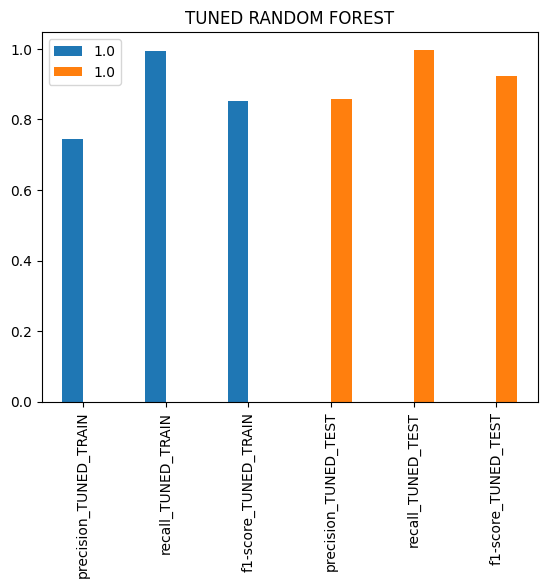

In [52]:
print('TUNED RANDOM FOREST')
TUNED_result.plot(kind = 'bar', legend = True)
plt.title('TUNED RANDOM FOREST')

### For probability output:

In [ ]:
#model_tuned.fit(X_train, y_train)
#model_tuned_y_pred_proba_RF_0 = RF_model_tuned.predict_proba(X_test)[:,0]
#model_tuned_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]

In [54]:
import time
start_time = time.time()

RF_model_tuned.fit(X_train, y_train)

model_tuned_y_pred_RF = RF_model_tuned.predict(X_test)
print("--- %s seconds ---" % (time.time() - start_time))
model_tuned_y_pred_RF

--- 199.19476199150085 seconds ---


array([0., 0., 0., ..., 0., 0., 0.])

In [55]:
#model_tuned.fit(X_train, y_train)
model_tuned_y_pred_proba_RF_0 = RF_model_tuned.predict_proba(X_test)[:,0]
model_tuned_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]

In [56]:
RF_tuned_pred_proba_RF_0 = pd.DataFrame(model_tuned_y_pred_proba_RF_0)
RF_tuned_pred_proba_RF_1 = pd.DataFrame(model_tuned_y_pred_proba_RF_1)
RF_tuned_pred_proba_RF_0.head(3), RF_tuned_pred_proba_RF_1.head(3)

(          0
 0  0.815645
 1  0.987779
 2  0.993984,
           0
 0  0.184355
 1  0.012221
 2  0.006016)

In [57]:
RF_tuned_pred_class = pd.DataFrame(model_tuned_y_pred_RF)
RF_tuned_pred_class['binary_prediciton'] =  model_tuned_y_pred_RF
RF_tuned_pred_class = RF_tuned_pred_class[['binary_prediciton']]  
RF_tuned_pred_class.head(4)

,binary_prediciton
0,0.0
1,0.0
2,0.0
3,0.0


In [58]:
RF_tuned_pred_proba_RF_0_1 = pd.merge(RF_tuned_pred_proba_RF_0, RF_tuned_pred_proba_RF_1, left_index=True, right_index=True)
RF_tuned_pred_prob = pd.merge(RF_tuned_pred_proba_RF_0_1, RF_tuned_pred_class, left_index=True, right_index=True)
RF_tuned_pred_prob.head(5)

,0_x,0_y,binary_prediciton
0,0.815645,0.184355,0.0
1,0.987779,0.012221,0.0
2,0.993984,0.006016,0.0
3,0.968453,0.031547,0.0
4,0.924687,0.075313,0.0


In [59]:
RF_tuned_pred_prob['binary_prediciton'].value_counts()

binary_prediciton
0.0    16063
1.0      400
Name: count, dtype: int64

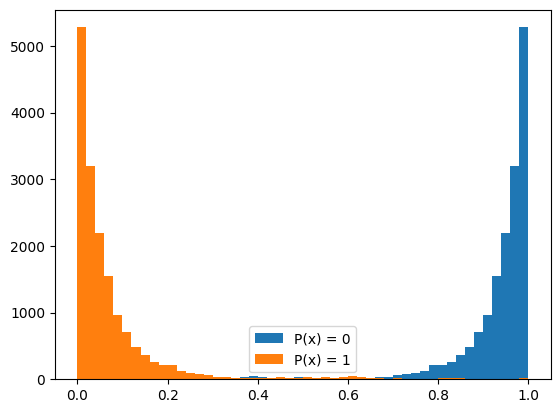

In [60]:
plt.hist(RF_tuned_pred_prob['0_x'], bins= 50, label = 'P(x) = 0')
plt.hist(RF_tuned_pred_prob['0_y'], bins= 50, label = 'P(x) = 1')
plt.legend()

In [61]:
#df_predictions = pd.merge(df, RF_tuned_pred_prob, left_index=True, right_index=True)
#df_predictions.head(3)#.columns

In [62]:
df_NEW_predictions = pd.merge(df_new, RF_tuned_pred_prob, left_index=True, right_index=True)
df_NEW_predictions.head(4)#.columns

,Unnamed: 0,Addressbase UPRN,ABP_Classification_Desc,ABP_Classification_Code,Tenure_Desc,AgeBracket_EldParent,(H) Age - Fine,(H) Presence of Elderly Parent,(H) Number of Adults in Household,(H) Family Lifestage v3,...,VictimsInvolved,VictimType,WasRescued,Victim_Category,EvacuationAssistanceInvolved,EquipmentUsed,Incident?,0_x,0_y,binary_prediciton
0,0,10002188486,Detached,RD02,Owner,76+,11,0,4,12,...,0,0,0,0,0,0,N,0.815645,0.184355,0.0
1,1,10002188492,Semi-Detached,RD03,Owner,61 - 65,8,0,2,9,...,0,0,0,0,0,0,N,0.987779,0.012221,0.0
2,2,10002188491,Semi-Detached,RD03,Owner,56 - 60,7,0,3,8,...,0,0,0,0,0,0,N,0.993984,0.006016,0.0
3,3,10002188489,Semi-Detached,RD03,Owner,66 - 70,9,0,2,12,...,0,0,0,0,0,0,N,0.968453,0.031547,0.0


## AUC

In [63]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

### Random Forest BASELINE -- not tuned

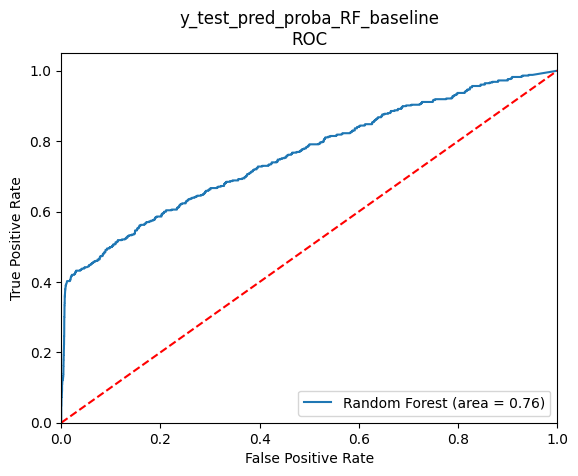

In [64]:
# ROC curve for the RandomForest baseline

#logit_roc_auc = roc_auc_score(y_train, y_train_pred_RF)
#fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_RF)

y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
#model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    y_test_pred_proba_RF_baseline)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba_RF_baseline)
y_test_pred_proba_RF_baseline
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('y_test_pred_proba_RF_baseline\nROC')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#logit_roc_auc = roc_auc_score(y_train, y_train_pred_RF)
#fpr, tpr, thresholds = roc_curve(y_train, y_train_pred_RF)

### Random Forest Tuned

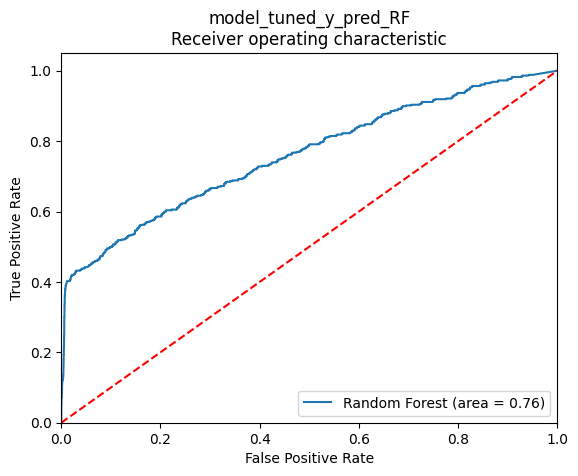

In [65]:
#y_test_pred_proba_RF_baseline =  pipeline_Random_Forest.predict_proba(X_test)[:,1]
# change for 
model_y_pred_proba_RF_1 = RF_model_tuned.predict_proba(X_test)[:,1]
logit_roc_auc = roc_auc_score(y_test,    model_y_pred_proba_RF_1)
fpr, tpr, thresholds = roc_curve(y_test, model_y_pred_proba_RF_1)
model_y_pred_proba_RF_1


# ROC curve for the RandomForest tuned
plt.figure()
plt.plot(fpr, tpr, label='Random Forest (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('model_tuned_y_pred_RF\nReceiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [79]:
print(classification_report(y_test, model_tuned_y_pred_RF))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98     15956
         1.0       0.51      0.40      0.45       507

    accuracy                           0.97     16463
   macro avg       0.75      0.70      0.72     16463
weighted avg       0.97      0.97      0.97     16463



In [82]:
target_names = ['0', '1']
print("RF_model_tuned_y_pred")
print(classification_report(y_train, RF_model_tuned_y_pred, target_names=target_names))

RF_model_tuned_y_pred
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     63823
           1       0.75      0.99      0.85      2028

    accuracy                           0.99     65851
   macro avg       0.87      0.99      0.92     65851
weighted avg       0.99      0.99      0.99     65851



In [ ]:
UPRN_X_Y = pd.read_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/ARCGIS/UPRN_Gazetteer_data/Gazetter_UPRN_District.xlsx')

In [ ]:
UPRN_X_Y['FCL_URN'].info()

In [ ]:
df_NEW_map=df_NEW_predictions.merge(UPRN_X_Y, left_on = 'Addressbase UPRN', right_on = 'FCL_URN', how = 'inner')
df_NEW_map.head(2)
#df_map.columns

In [ ]:
df_NEW_map.shape

In [ ]:
df_NEW_map = df_NEW_map.drop_duplicates(subset='Addressbase UPRN', keep="first")

In [ ]:
df_NEW_map.shape

In [ ]:
df_NEW_map.to_excel('S:/AdamMason/PROJECTS/C_SPark_Home_Safety/df_NEW_map.xlsx')

In [ ]:

df_NEW_map.to_csv('S:/AdamMason/PROJECTS/C_SPark_Home_Safety/df_NEW_map.csv')

In [ ]:

rank_test_score_0 = RF_random_search.cv_results_['split0_test_score']
rank_test_score_1 = RF_random_search.cv_results_['split1_test_score']
rank_test_score_2 =  RF_random_search.cv_results_['split2_test_score']
rank_test_score_3 =  RF_random_search.cv_results_['split3_test_score']
rank_test_score_4 = RF_random_search.cv_results_['split4_test_score']
mean_test_Score  = RF_random_search.cv_results_['mean_test_score']
#print('param_classifier'   , gridsearch.cv_results_['mean_test_score'])

#data = pd.merge(rank_test_score_0, rank_test_score_1, rank_test_score_2, left_index=True, right_index=True)
dfs = [rank_test_score_0, rank_test_score_1, rank_test_score_2,rank_test_score_3,rank_test_score_4]#, mean_test_Score]
dfs = pd.DataFrame(dfs)
dfs

In [ ]:
from sklearn.metrics import classification_report
target_names = ['0', '1']

y_train_pred = RF_random_search.predict(X_train)

print(classification_report(y_train, y_train_pred, target_names=target_names))

In [ ]:
importances = pipeline_Random_Forest['classifier'].feature_importances_
 
# 3. Combine them into a sorted DataFrame
feature_importance_df = pd.DataFrame({
#'Feature': feature_names,
'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_names = df.columns
feature_names
print(feature_importance_df)

In [ ]:
feature_names = pipeline_Random_Forest['preprocessor'].get_feature_names_out()
importances = pipeline_Random_Forest['classifier'].feature_importances_
df_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
df_importance = df_importance.sort_values('importance', ascending=False)

print(df_importance.sort_values('importance', ascending=False).head(30))

In [ ]:
#df_importance.to_excel('C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/OUTPUT/feature_importance.xlsx')

In [ ]:
df_importance.sort_values("importance", ascending =False).head(20).plot(kind = 'bar', figsize=(12,12))

In [ ]:
# dfFeatures = pd.DataFrame({'Features': feature_names.tolist(), 'Importances': clf.feature_importances_})
# dfFeatures.sort_values(by='Importances',ascending  =False).head(5)

## Bagging Ensemble:
#### Not sure if these steps are necessary at all?

In [ ]:
from sklearn.ensemble import BaggingClassifier


In [ ]:
X_train

In [ ]:
import seaborn as sns
import numpy as np

acc = []
for i in range(1,10):
    #acc = []
    ensemble_2 = BaggingClassifier(
        estimator = best_RF_model(),
        n_estimators = i,
        random_state = 5)
    ensemble_2.fit(X = X_train, y = y_train)
    acc_score = ensemble_2.score(X_test, y_test)
    acc.append(acc_score)
    #print(classification_report(y_test, y_pred))
    #print(f"Ensemble accuracy on unseen data: {ensemble_2.score(X_test, y_test):.2f}")
x_vals = np.linspace(0,40,39)
len(x_vals)
ax = sns.lineplot(x = x_vals, y = acc)
ax = sns.lineplot(x= acc.index(max(acc))+1, y=[0,max(acc)], color = 'black')
ax.set(xlabel='n_estimators', ylabel='accuraacy_score')
plt.show()